Desarrollado por Victoria Gutiérrez, G.Vinueza - UdeSA
#PCA


Importo librerías necesarias

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

import warnings
warnings.filterwarnings('ignore')

Obtengo un dataset

In [2]:
USArrests = sm.datasets.get_rdataset("USArrests", "datasets")
datos = USArrests.data
datos.head()

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


Escalo los datos

In [3]:
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(datos)

Calculo matriz de covarianzas de mi dataset

In [4]:
covarianzas = np.cov(datos_escalados.T)
covarianzas

array([[1.02040816, 0.81823807, 0.07099247, 0.57508044],
       [0.81823807, 1.02040816, 0.2641548 , 0.67881758],
       [0.07099247, 0.2641548 , 1.02040816, 0.41973595],
       [0.57508044, 0.67881758, 0.41973595, 1.02040816]])

Calculo autovalores y autovectores

In [5]:
autovalores, autovectores = np.linalg.eig(covarianzas)

In [6]:
autovalores

array([2.53085875, 1.00996444, 0.17696948, 0.36383998])

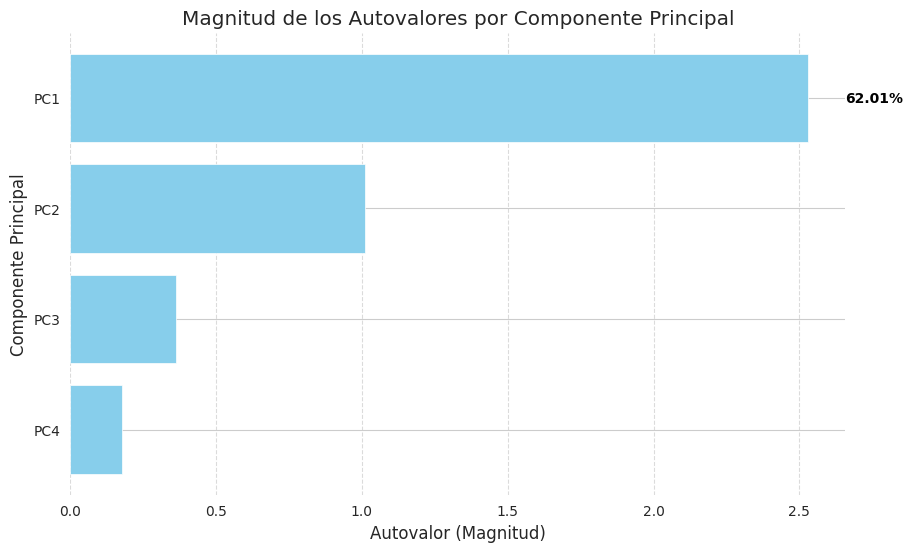

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

total_autovalores = np.sum(autovalores)
porcentaje_autovalores = (autovalores / total_autovalores) * 100

# Sort eigenvalues in descending order for better visualization
autovalores_sorted_idx = np.argsort(autovalores)[::-1]
autovalores_plot = autovalores[autovalores_sorted_idx]
porcentaje_autovalores_plot = porcentaje_autovalores[autovalores_sorted_idx]

plt.figure(figsize=(10, 6))
plt.barh(y=[f'PC{i+1}' for i in range(len(autovalores_plot))], width=autovalores_plot, color='skyblue')
plt.xlabel('Autovalor (Magnitud)')
plt.ylabel('Componente Principal')
plt.title('Magnitud de los Autovalores por Componente Principal')

# Annotate the first bar with its percentage
plt.text(autovalores_plot[0] * 1.05, 0, f'{porcentaje_autovalores_plot[0]:.2f}%', va='center', color='black', fontweight='bold')

plt.gca().invert_yaxis() # To have PC1 at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
sns.despine(left=True, bottom=True)
plt.show()

In [8]:
autovectores

array([[ 0.53589947,  0.41818087,  0.6492278 , -0.34123273],
       [ 0.58318363,  0.1879856 , -0.74340748, -0.26814843],
       [ 0.27819087, -0.87280619,  0.13387773, -0.37801579],
       [ 0.54343209, -0.16731864,  0.08902432,  0.81777791]])

Varianza explicada acumulada

In [9]:
indices_ordenados = np.argsort(autovalores)[::-1]

autovalores_ordenados = autovalores[indices_ordenados]
autovectores_ordenados = autovectores[:, indices_ordenados]

var_exp = autovalores_ordenados / np.sum(autovalores_ordenados)
var_exp_acum = np.cumsum(var_exp)

resultados = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(var_exp))],
    'Varianza_Explicada': np.round(var_exp, 4),
    'Varianza_Acumulada': np.round(var_exp_acum, 4)
})

print(resultados)



  Componente  Varianza_Explicada  Varianza_Acumulada
0        PC1              0.6201              0.6201
1        PC2              0.2474              0.8675
2        PC3              0.0891              0.9566
3        PC4              0.0434              1.0000


Gráfico de la varianza explicada acumulada

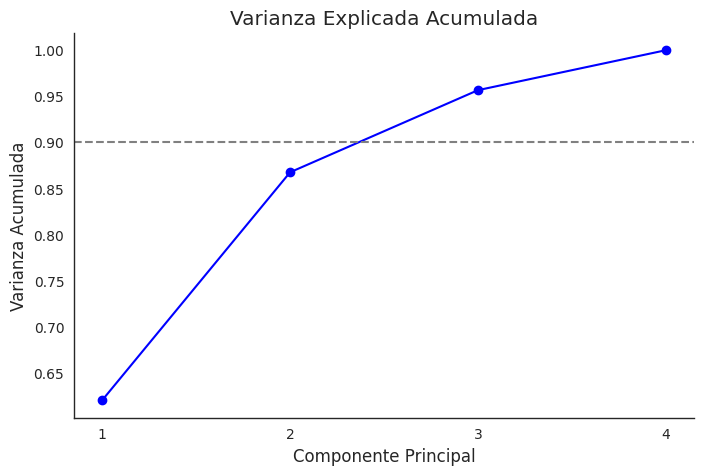

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")  # Sin fondo gris ni bordes

plt.figure(figsize=(8, 5))
plt.plot(range(1, 5), var_exp_acum[:4], marker='o', color='blue')
plt.axhline(y=0.9, color='gray', linestyle='--')
plt.xticks([1, 2, 3, 4])
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Explicada Acumulada')
sns.despine()  # Quita bordes superior y derecho
plt.grid(False)  # Quita grilla
plt.show()




Haciendolo directamente con scikit learn

In [26]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(datos_escalados)


PCA()

In [27]:
var_exp_acum = np.cumsum(pca.explained_variance_ratio_)
var_exp_acum

array([0.62006039, 0.86750168, 0.95664248, 1.        ])

In [28]:
componentes_4 = pca.components_[:4]

componentes_df = pd.DataFrame(componentes_4,
                             columns=datos.columns,
                             index=[f'PC{i+1}' for i in range(4)])

print(componentes_df)


       Murder   Assault  UrbanPop      Rape
PC1  0.535899  0.583184  0.278191  0.543432
PC2 -0.418181 -0.187986  0.872806  0.167319
PC3 -0.341233 -0.268148 -0.378016  0.817778
PC4 -0.649228  0.743407 -0.133878 -0.089024


In [29]:
datos_pca = pca.transform(datos_escalados)
print("Shape of original scaled data:", datos_escalados.shape)
print("Shape of data transformed to PC space:", datos_pca.shape)
print("First 5 rows of transformed data (PC1, PC2, etc.):")
print(datos_pca[:5])

Shape of original scaled data: (50, 4)
Shape of data transformed to PC space: (50, 4)
First 5 rows of transformed data (PC1, PC2, etc.):
[[ 0.98556588 -1.13339238 -0.44426879 -0.15626714]
 [ 1.95013775 -1.07321326  2.04000333  0.43858344]
 [ 1.76316354  0.74595678  0.05478082  0.83465292]
 [-0.14142029 -1.11979678  0.11457369  0.1828109 ]
 [ 2.52398013  1.54293399  0.5985568   0.34199648]]


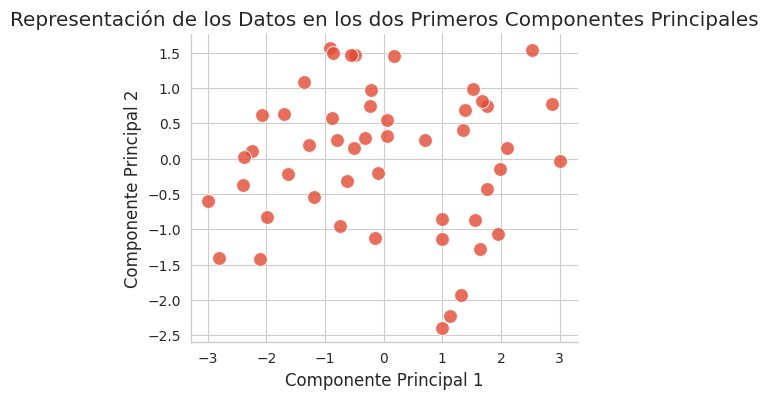

In [32]:
plt.figure(figsize=(5, 4))
sns.scatterplot(x=datos_pca[:, 0], y=datos_pca[:, 1], s=100, alpha=0.8)
plt.title('Representación de los Datos en los dos Primeros Componentes Principales')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
sns.despine()
plt.show()

Aplicamos KMeans

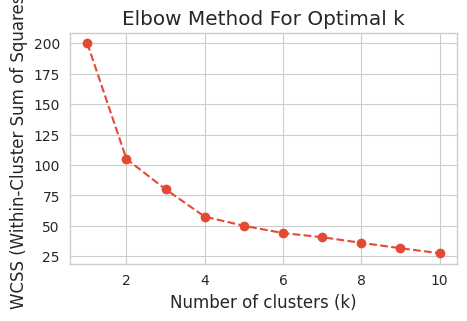

In [36]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(datos_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(5, 3))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

In [37]:
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(datos_pca)

print("First 5 cluster assignments:")
print(clusters[:5])

First 5 cluster assignments:
[1 3 3 1 3]



Create a scatter plot of PC1 versus PC2, coloring each point according to its assigned K-Means cluster.


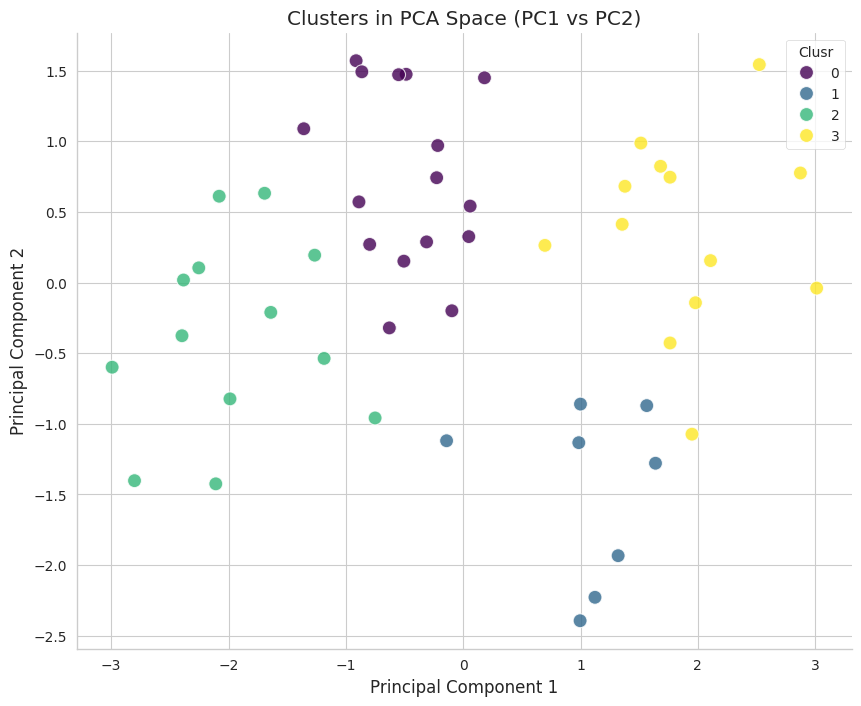

In [40]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=datos_pca[:, 0], y=datos_pca[:, 1], hue=clusters, palette='viridis', s=100, alpha=0.8)
plt.title('Clusters in PCA Space (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
sns.despine()
plt.legend(title='Clusr')
plt.show()

**Reasoning**:
The previous step successfully created a scatter plot of PC1 vs PC2 with clustered points. Now, I need to add the cluster centroids to this same plot as instructed by the main task to visualize where the center of each cluster lies in the PCA space.



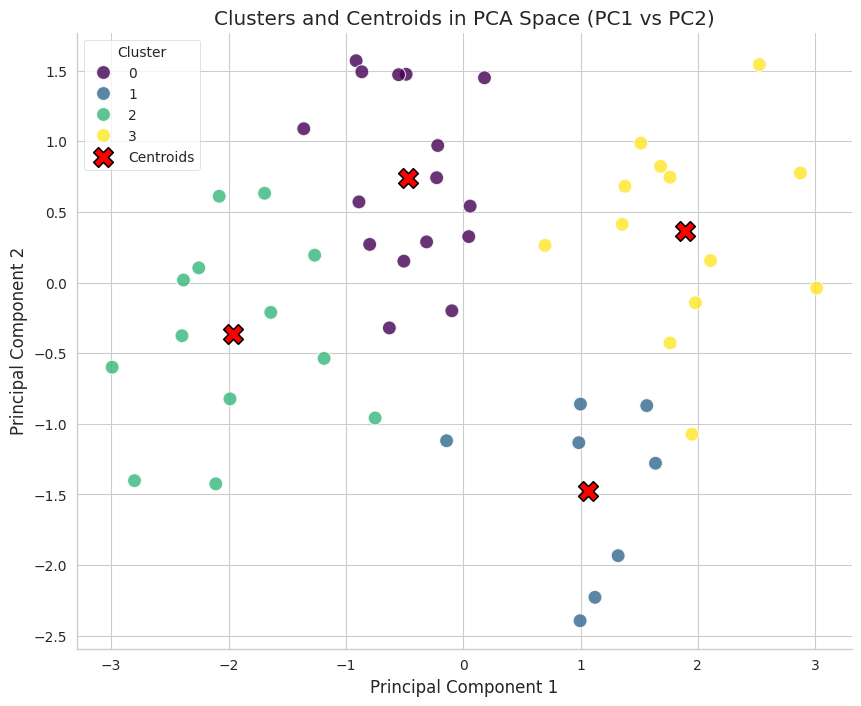

In [41]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=datos_pca[:, 0], y=datos_pca[:, 1], hue=clusters, palette='viridis', s=100, alpha=0.8, legend='full')

# Get the cluster centroids in PCA space
centroids = kmeans.cluster_centers_
sns.scatterplot(x=centroids[:, 0], y=centroids[:, 1], marker='X', s=200, color='red', edgecolor='black', label='Centroids', zorder=2)

plt.title('Clusters and Centroids in PCA Space (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
sns.despine()
plt.legend(title='Cluster')
plt.show()

**Reasoning**:
I need to analyze the characteristics of each cluster by looking at the mean of the original scaled features for each cluster. This will provide insights into what each cluster represents in the context of the initial data attributes.



In [42]:
cluster_characteristics = pd.DataFrame(datos_escalados, columns=datos.columns)
cluster_characteristics['Cluster'] = clusters

# Calculate the mean of original scaled features for each cluster
mean_scaled_features = cluster_characteristics.groupby('Cluster').mean()

print("Mean of original scaled features for each cluster:")
print(mean_scaled_features)

Mean of original scaled features for each cluster:
           Murder   Assault  UrbanPop      Rape
Cluster                                        
0       -0.494407 -0.386484  0.581676 -0.264310
1        1.426224  0.883211 -0.822791  0.019467
2       -0.971303 -1.117836 -0.939550 -0.976578
3        0.702127  1.049994  0.729974  1.289904


## Analyze Cluster Characteristics with Original Variables

### Subtask:
Examine the mean of the original scaled features for each cluster to understand what differentiates the groups identified by K-Means.


## Summary:

### Data Analysis Key Findings
*   K-Means clustering was performed on the principal components data (`datos_pca`) using `k=4`.
*   The clusters were visualized on a scatter plot of PC1 versus PC2, with each point colored according to its assigned cluster.
*   The centroids of the four clusters were also plotted on the same PCA scatter plot, marked as red 'X's, to show their central positions within the clusters.
*   The mean of the original scaled features ('Murder', 'Assault', 'UrbanPop', and 'Rape') was calculated for each cluster to identify and understand the distinct characteristics of the groups.

### Insights or Next Steps
*   Further analysis could involve interpreting the principal components to understand what underlying factors they represent, which would help in better understanding the cluster characteristics.
*   The calculated mean scaled features for each cluster should be examined in detail to profile each cluster (e.g., "Cluster 0 has high murder rates, low assault, etc."), which can then inform targeted strategies or further investigation.
